## Referencias

El dataset se obtuvo de: https://www.kaggle.com/datasets/ammarnassanalhajali/pklot-dataset/data

Y se tomó como ayuda el siguiente notebook: https://www.kaggle.com/code/emptysuername/s9-aiot-plot-cam


## Setup

Instalacion de librerias

In [ ]:
!pip install tensorflow
!pip install opencv-python
!pip install kagglehub
!pip install numpy
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.1 MB/s eta 0:00:00


Imports Necesarios

In [ ]:
from PIL import Image
import shutil
from google.colab.patches import cv2_imshow
import tensorflow as tf
import kagglehub
import ultralytics
from ultralytics import YOLO
import glob

import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import random
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as T

import warnings

Configuración de seeds aleatorias para reproducibilidad y uso de GPU

In [ ]:
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Descarga del Data Set y Estadísticas del Data Set

Cargar imagenes desde kaggle y separar conjunto de imágenes de entrenamiento, prueba y validación.

In [ ]:
ROOT = kagglehub.dataset_download("ammarnassanalhajali/pklot-dataset")
print("Path to dataset files:", ROOT)

TRAIN_DIR = ROOT + "/train"
TEST_DIR  = ROOT + "/test"
VAL_DIR   = ROOT + "/valid"

Using Colab cache for faster access to the 'pklot-dataset' dataset.
Path to dataset files: /kaggle/input/pklot-dataset


Resumen de la información del dataset. La cantidad de imágenes de entrenamiento, validación y test, y las categorías del dataset.

In [ ]:
def load_coco_annotations(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

train_data = load_coco_annotations(os.path.join(TRAIN_DIR, '_annotations.coco.json'))
val_data = load_coco_annotations(os.path.join(VAL_DIR, '_annotations.coco.json'))
test_data = load_coco_annotations(os.path.join(TEST_DIR, '_annotations.coco.json'))

print("Train images:     ", len(train_data['images']))
print("Validation images:", len(val_data['images']))
print("Test images:      ", len(test_data['images']))
print("\nCategories:", train_data['categories'])

Train images:      8691
Validation images: 2483
Test images:       1242

Categories: [{'id': 0, 'name': 'spaces', 'supercategory': 'none'}, {'id': 1, 'name': 'space-empty', 'supercategory': 'spaces'}, {'id': 2, 'name': 'space-occupied', 'supercategory': 'spaces'}]


Más estadísticas del data set. Incluye cantidad de imágenes, anotaciones, y estadísticas de las anotaciones para cada conjunto de imágenes.

In [ ]:
# Analyze dataset statistics
def analyze_dataset(data, name):
    """Analyze and print dataset statistics"""
    print(f"\n{'='*50}")
    print(f"{name} Dataset Statistics")
    print(f"{'='*50}")

    # Count annotations per category
    category_counts = defaultdict(int)
    bbox_sizes = []

    for ann in data['annotations']:
        category_counts[ann['category_id']] += 1
        bbox_sizes.append(ann['area'])

    # Map category IDs to names
    cat_id_to_name = {cat['id']: cat['name'] for cat in data['categories']}

    print(f"\nTotal images: {len(data['images'])}")
    print(f"Total annotations: {len(data['annotations'])}")
    print(f"\nAnnotations per category:")
    for cat_id, count in category_counts.items():
        print(f"  {cat_id_to_name.get(cat_id, 'Unknown')}: {count}")

    print(f"\nBounding box area statistics:")
    print(f"  Mean: {np.mean(bbox_sizes):.2f}")
    print(f"  Median: {np.median(bbox_sizes):.2f}")
    print(f"  Min: {np.min(bbox_sizes):.2f}")
    print(f"  Max: {np.max(bbox_sizes):.2f}")

    return category_counts, bbox_sizes

train_stats, train_bbox_sizes = analyze_dataset(train_data, "TRAIN")
val_stats, val_bbox_sizes = analyze_dataset(val_data, "VALIDATION")
test_stats, test_bbox_sizes = analyze_dataset(test_data, "TEST")


TRAIN Dataset Statistics

Total images: 8691
Total annotations: 497856

Annotations per category:
  space-occupied: 231948
  space-empty: 265908

Bounding box area statistics:
  Mean: 1902.84
  Median: 1439.25
  Min: 544.00
  Max: 10666.25

VALIDATION Dataset Statistics

Total images: 2483
Total annotations: 143316

Annotations per category:
  space-occupied: 69687
  space-empty: 73629

Bounding box area statistics:
  Mean: 1889.75
  Median: 1439.25
  Min: 544.00
  Max: 10666.25

TEST Dataset Statistics

Total images: 1242
Total annotations: 70684

Annotations per category:
  space-empty: 36584
  space-occupied: 34100

Bounding box area statistics:
  Mean: 1919.19
  Median: 1441.75
  Min: 544.00
  Max: 10666.25


Visualización Bounding Boxes del Data Set

In [ ]:
def visualize_annotations(data, img_dir, num_samples=6):
    """Visualize sample images with annotations"""
    cat_id_to_name = {cat['id']: cat['name'] for cat in data['categories']}
    colors = {
        1: (0, 255, 0),    # Green for empty
        2: (255, 0, 0)     # Red for occupied
    }

    # Create image_id to annotations mapping
    img_id_to_anns = defaultdict(list)
    for ann in data['annotations']:
        img_id_to_anns[ann['image_id']].append(ann)

    # Sample random images
    sample_images = random.sample(data['images'], min(num_samples, len(data['images'])))

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    for idx, img_info in enumerate(sample_images):
        if idx >= num_samples:
            break

        img_path = os.path.join(img_dir, img_info['file_name'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw annotations
        annotations = img_id_to_anns[img_info['id']]
        empty_count = 0
        occupied_count = 0

        for ann in annotations:
            x, y, w, h = map(int, ann['bbox'])
            cat_id = ann['category_id']

            if cat_id == 1:
                empty_count += 1
            elif cat_id == 2:
                occupied_count += 1

            color = colors.get(cat_id, (255, 255, 255))
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)

            # Add label
            label = cat_id_to_name.get(cat_id, 'unknown')
            cv2.putText(img, f"{ann['id']}", (x, y - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

        axes[idx].imshow(img)
        axes[idx].set_title(f"Empty: {empty_count} | Occupied: {occupied_count}",
                           fontsize=10)
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('sample_annotations.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize samples from each dataset
print("Training samples:")
visualize_annotations(train_data, TRAIN_DIR, num_samples=6)

print("\nValidation samples:")
visualize_annotations(val_data, VAL_DIR, num_samples=6)

Output hidden; open in https://colab.research.google.com to view.

# Pre Training utilities

Utilidades para acceder a datos del data set.

In [ ]:
class ParkingLotDataset(Dataset):
    def __init__(self, coco_data, img_dir, transforms=None):
        self.coco_data = coco_data
        self.img_dir = img_dir
        self.transforms = transforms

        # Create mappings
        self.images = coco_data['images']
        self.img_id_to_anns = defaultdict(list)
        for ann in coco_data['annotations']:
            self.img_id_to_anns[ann['image_id']].append(ann)

        # Filter out images with no annotations
        self.valid_images = []
        for img in self.images:
            if len(self.img_id_to_anns[img['id']]) > 0:
                self.valid_images.append(img)

        print(f"Total images: {len(self.images)}")
        print(f"Images with annotations: {len(self.valid_images)}")
        print(f"Filtered out: {len(self.images) - len(self.valid_images)} images")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_info = self.valid_images[idx]
        img_path = os.path.join(self.img_dir, img_info['file_name'])

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError(f"Failed to load image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        img /= 255.0

        # Get annotations
        annotations = self.img_id_to_anns[img_info['id']]

        boxes = []
        labels = []
        ann_ids = []
        areas = []

        for ann in annotations:
            x, y, w, h = ann['bbox']

            # Skip invalid boxes
            if w <= 0 or h <= 0:
                continue

            # Convert to [x1, y1, x2, y2] format
            x1, y1, x2, y2 = x, y, x + w, y + h

            # Ensure boxes are within image bounds
            x1 = max(0, min(x1, img_info['width']))
            y1 = max(0, min(y1, img_info['height']))
            x2 = max(0, min(x2, img_info['width']))
            y2 = max(0, min(y2, img_info['height']))

            # Skip if box becomes invalid after clipping
            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(ann['category_id'])
            ann_ids.append(ann['id'])
            areas.append((x2 - x1) * (y2 - y1))

        # Ensure we have at least one valid box
        if len(boxes) == 0:
            # This shouldn't happen since we filtered, but just in case
            # Add a dummy box (will be handled by filtering)
            boxes = [[0, 0, 1, 1]]
            labels = [1]
            ann_ids = [-1]
            areas = [1]

        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)

        # Create target dictionary
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_info['id']]),
            'area': areas,
            'iscrowd': torch.zeros((len(boxes),), dtype=torch.int64),
            'ann_ids': ann_ids
        }

        # Apply transforms
        if self.transforms:
            img = self.transforms(img)
        else:
            img = torch.from_numpy(img).permute(2, 0, 1)

        return img, target

# Test the dataset
train_dataset = ParkingLotDataset(train_data, TRAIN_DIR)
print(f"\nDataset size: {len(train_dataset)}")

# Test loading one sample
img, target = train_dataset[0]
print(f"Image shape: {img.shape}")
print(f"Number of boxes: {len(target['boxes'])}")
print(f"Labels: {target['labels'][:5]}...")
print(f"Boxes shape: {target['boxes'].shape}")

Total images: 8691
Images with annotations: 8502
Filtered out: 189 images

Dataset size: 8502
Image shape: torch.Size([3, 640, 640])
Number of boxes: 40
Labels: tensor([2, 2, 2, 2, 2])...
Boxes shape: torch.Size([40, 4])


Creación de lotes para el entrenamiento del modelo.

In [ ]:
def get_transform(train=True):
    """Get transformation pipeline"""
    # For training, we keep it simple since Faster R-CNN handles augmentation internally
    # Just normalize the images
    return None

def collate_fn(batch):
    """Custom collate function for DataLoader"""
    return tuple(zip(*batch))

# Create datasets
train_dataset = ParkingLotDataset(train_data, TRAIN_DIR, transforms=get_transform(train=True))
val_dataset = ParkingLotDataset(val_data, VAL_DIR, transforms=get_transform(train=False))
test_dataset = ParkingLotDataset(test_data, TEST_DIR, transforms=get_transform(train=False))

# Create dataloaders
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Total images: 8691
Images with annotations: 8502
Filtered out: 189 images
Total images: 2483
Images with annotations: 2424
Filtered out: 59 images
Total images: 1242
Images with annotations: 1216
Filtered out: 26 images
Train batches: 2126
Val batches: 606
Test batches: 1216


# Entrenamiento del modelo

In [ ]:
def get_model(num_classes):
    """
    Get Faster R-CNN model with ResNet50 backbone
    num_classes includes background, so we need 3 classes:
    0: background, 1: space-empty, 2: space-occupied
    """
    # Load pre-trained model
    model = fasterrcnn_resnet50_fpn(pretrained=True)

    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# Create model
num_classes = 3  # background + space-empty + space-occupied
model = get_model(num_classes)
model.to(device)

print("Model created successfully!")
print(f"Number of classes: {num_classes}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 171MB/s]


Model created successfully!
Number of classes: 3


Utilidades para entrenamiento del modelo.

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    num_batches = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch}")

    for images, targets in progress_bar:
        # Filter out samples with no boxes
        valid_samples = []
        valid_targets = []

        for img, target in zip(images, targets):
            if len(target['boxes']) > 0:
                valid_samples.append(img)
                valid_targets.append(target)

        # Skip batch if no valid samples
        if len(valid_samples) == 0:
            continue

        images = list(image.to(device) for image in valid_samples)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v
                    for k, v in t.items()} for t in valid_targets]

        try:
            # Forward pass
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            # Backward pass
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            total_loss += losses.item()
            num_batches += 1
            progress_bar.set_postfix({'loss': losses.item()})
        except Exception as e:
            print(f"\nError in batch: {e}")
            continue

    return total_loss / max(num_batches, 1)

@torch.no_grad()
def evaluate(model, data_loader, device):
    """Evaluate model - model needs to be in train mode to compute losses"""
    model.train()  # Keep in train mode to get loss_dict
    total_loss = 0
    num_batches = 0

    for images, targets in tqdm(data_loader, desc="Evaluating"):
        # Filter out samples with no boxes
        valid_samples = []
        valid_targets = []

        for img, target in zip(images, targets):
            if len(target['boxes']) > 0:
                valid_samples.append(img)
                valid_targets.append(target)

        if len(valid_samples) == 0:
            continue

        images = list(image.to(device) for image in valid_samples)
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v
                    for k, v in t.items()} for t in valid_targets]

        try:
            # Forward pass (model in train mode returns losses)
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()
            num_batches += 1
        except Exception as e:
            print(f"\nError in batch: {e}")
            continue

    return total_loss / max(num_batches, 1)

Entrenamiento y Descarga del modelo

In [18]:
# Training parameters
NUM_EPOCHS = 10
LEARNING_RATE = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Training history
history = {
    'train_loss': [],
    'val_loss': []
}

print("Starting training...")
print(f"Device: {device}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print("-" * 50)

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)

    # Evaluate
    val_loss = evaluate(model, val_loader, device)

    # Update learning rate
    lr_scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 50)

print("Training completed!")

# Save model
torch.save(model.state_dict(), 'parking_lot_detector.pth')
print("Model saved as 'parking_lot_detector.pth'")

Starting training...
Device: cuda
Epochs: 10
Learning rate: 0.005
Batch size: 4
--------------------------------------------------


Evaluating: 100%|██████████| 606/606 [04:15<00:00,  2.37it/s]



Epoch 1/10
Train Loss: 0.2204
Val Loss: 0.1267
Learning Rate: 0.005000
--------------------------------------------------


Evaluating: 100%|██████████| 606/606 [04:17<00:00,  2.36it/s]



Epoch 2/10
Train Loss: 0.0758
Val Loss: 0.0578
Learning Rate: 0.005000
--------------------------------------------------


...


Epoch 8/10
Train Loss: 0.0275
Val Loss: 0.0288
Learning Rate: 0.000050
--------------------------------------------------


Evaluating: 100%|██████████| 606/606 [04:17<00:00,  2.35it/s]



Epoch 9/10
Train Loss: 0.0273
Val Loss: 0.0288
Learning Rate: 0.000005
--------------------------------------------------


Evaluating: 100%|██████████| 606/606 [04:16<00:00,  2.36it/s]



Epoch 10/10
Train Loss: 0.0271
Val Loss: 0.0287
Learning Rate: 0.000005
--------------------------------------------------
Training completed!
Model saved as 'parking_lot_detector.pth'


Resumen del Entrenamiento.

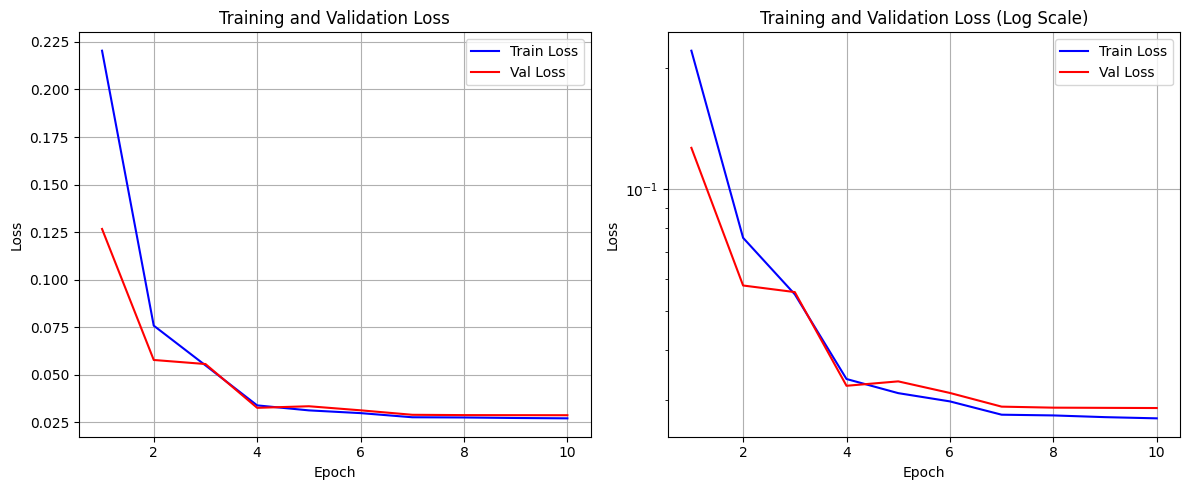

In [19]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS + 1), history['train_loss'], 'b-', label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), history['val_loss'], 'r-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS + 1), history['train_loss'], 'b-', label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), history['val_loss'], 'r-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Uso del modelo y Estadísticas de Predicción

In [20]:
@torch.no_grad()
def detect_parking_spots(model, image, device, threshold=0.5):
    """Detect parking spots in an image"""
    model.eval()

    # Prepare image
    img_tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(device)

    # Inference
    predictions = model(img_tensor)[0]

    # Filter by confidence threshold
    keep = predictions['scores'] > threshold
    boxes = predictions['boxes'][keep].cpu().numpy()
    labels = predictions['labels'][keep].cpu().numpy()
    scores = predictions['scores'][keep].cpu().numpy()

    return boxes, labels, scores

def visualize_predictions(image_path, model, device, threshold=0.5):
    """Visualize predictions on an image"""
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # Detect
    boxes, labels, scores = detect_parking_spots(model, img, device, threshold)

    # Draw results
    img_display = (img * 255).astype(np.uint8).copy()

    empty_count = 0
    occupied_count = 0

    colors = {
        1: (0, 255, 0),    # Green for empty
        2: (255, 0, 0)     # Red for occupied
    }

    label_names = {
        1: 'Empty',
        2: 'Occupied'
    }

    for idx, (box, label, score) in enumerate(zip(boxes, labels, scores)):
        x1, y1, x2, y2 = map(int, box)
        color = colors.get(label, (255, 255, 255))

        if label == 1:
            empty_count += 1
        elif label == 2:
            occupied_count += 1

        # Draw box
        cv2.rectangle(img_display, (x1, y1), (x2, y2), color, 2)

        # Draw label with ID
        label_text = f"ID:{idx} {label_names.get(label, 'Unknown')} {score:.2f}"
        cv2.putText(img_display, label_text, (x1, y1 - 5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return img_display, empty_count, occupied_count, len(boxes)

# Test on validation images
sample_indices = random.sample(range(len(val_dataset)), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, sample_idx in enumerate(sample_indices):
    img_info = val_data['images'][sample_idx]
    img_path = os.path.join(VAL_DIR, img_info['file_name'])

    img_result, empty, occupied, total = visualize_predictions(
        img_path, model, device, threshold=0.7
    )

    axes[idx].imshow(img_result)
    axes[idx].set_title(
        f"Total: {total} | Empty: {empty} | Occupied: {occupied}",
        fontsize=10
    )
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [21]:
def calculate_metrics(model, data_loader, device, iou_threshold=0.5, conf_threshold=0.5):
    """Calculate detection metrics"""
    model.eval()

    all_precisions = []
    all_recalls = []
    total_empty_gt = 0
    total_occupied_gt = 0
    total_empty_pred = 0
    total_occupied_pred = 0

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Calculating metrics"):
            images = list(image.to(device) for image in images)

            for img, target in zip(images, targets):
                # Predictions
                pred = model([img])[0]

                # Filter by confidence
                keep = pred['scores'] > conf_threshold
                pred_boxes = pred['boxes'][keep].cpu().numpy()
                pred_labels = pred['labels'][keep].cpu().numpy()

                # Ground truth
                gt_boxes = target['boxes'].cpu().numpy()
                gt_labels = target['labels'].cpu().numpy()

                # Count by category
                total_empty_gt += np.sum(gt_labels == 1)
                total_occupied_gt += np.sum(gt_labels == 2)
                total_empty_pred += np.sum(pred_labels == 1)
                total_occupied_pred += np.sum(pred_labels == 2)

    print("\n" + "="*50)
    print("Detection Statistics")
    print("="*50)
    print(f"Ground Truth - Empty: {total_empty_gt}, Occupied: {total_occupied_gt}")
    print(f"Predicted - Empty: {total_empty_pred}, Occupied: {total_occupied_pred}")
    print(f"Total Ground Truth: {total_empty_gt + total_occupied_gt}")
    print(f"Total Predicted: {total_empty_pred + total_occupied_pred}")

# Calculate metrics on validation set
calculate_metrics(model, val_loader, device, conf_threshold=0.7)

Calculating metrics: 100%|██████████| 606/606 [04:07<00:00,  2.45it/s]


Detection Statistics
Ground Truth - Empty: 73629, Occupied: 69687
Predicted - Empty: 71417, Occupied: 70425
Total Ground Truth: 143316
Total Predicted: 141842


In [22]:
# Run inference on test set and save results
def process_test_set(model, test_loader, device, output_dir='test_results', threshold=0.7):
    """Process entire test set and save results"""
    os.makedirs(output_dir, exist_ok=True)

    model.eval()
    results = []

    with torch.no_grad():
        for idx, (images, targets) in enumerate(tqdm(test_loader, desc="Processing test set")):
            img = images[0].to(device)
            target = targets[0]

            # Get image info
            img_info = test_data['images'][idx]
            img_path = os.path.join(TEST_DIR, img_info['file_name'])

            # Detect
            img_np = cv2.imread(img_path)
            img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

            boxes, labels, scores = detect_parking_spots(model, img_np, device, threshold)

            empty_count = np.sum(labels == 1)
            occupied_count = np.sum(labels == 2)

            results.append({
                'image_id': img_info['id'],
                'file_name': img_info['file_name'],
                'total_spots': len(boxes),
                'empty_spots': int(empty_count),
                'occupied_spots': int(occupied_count),
                'detections': len(boxes)
            })

    # Save results to CSV
    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join(output_dir, 'test_results.csv'), index=False)

    print(f"\nTest set processing complete!")
    print(f"Results saved to {output_dir}/test_results.csv")
    print(f"\nSummary statistics:")
    print(results_df[['total_spots', 'empty_spots', 'occupied_spots']].describe())

    return results_df

# Process test set
test_results = process_test_set(model, test_loader, device)

# Display sample results
print("\nSample results:")
print(test_results.head(10))

Processing test set: 100%|██████████| 1216/1216 [02:08<00:00,  9.46it/s]



Test set processing complete!
Results saved to test_results/test_results.csv

Summary statistics:
       total_spots  empty_spots  occupied_spots
count  1216.000000  1216.000000     1216.000000
mean     56.914474    29.233553       27.680921
std      31.059496    30.482994       27.095870
min      28.000000     0.000000        0.000000
25%      28.000000     3.000000        2.000000
50%      40.000000    26.000000       26.000000
75%     100.000000    40.000000       40.000000
max     100.000000   100.000000       99.000000

Sample results:
   image_id                                          file_name  total_spots  \
0         0  2012-11-06_13_43_31_jpg.rf.00207754dbce0d625d2...           82   
1         1  2012-10-17_08_34_38_jpg.rf.00872f80c0883729955...           99   
2         2  2013-03-02_08_00_02_jpg.rf.0215040aaef9b537ea6...           40   
3         3  2012-09-12_08_15_53_jpg.rf.025635f821fe24c12ab...          100   
4         4  2013-03-12_15_05_10_jpg.rf.0215071ec24d56a11